# NASDAQ-100 — 1.1-B Data Preparation

**Goal:** Transform the raw OHLCV dataset into a clean, model-ready feature matrix.  
Every decision here is grounded in the EDA findings from notebook `1.1-A`.

| EDA Finding | Action taken here |
|---|---|
| Prices are right-skewed | Use log prices & log returns |
| Returns have fat tails | Winsorise at 1st / 99th percentile |
| Volume is right-skewed | Use log₁₀(volume + 1) |
| OHLC columns are highly collinear | Use derived candle features only |
| Cross-ticker correlations cluster | Build item-similarity matrix |
| Some tickers have shorter histories | Filter; document survivorship bias |
| Zero-volume rows exist | Replace → forward-fill |
| Outlier returns are real market events | Winsorise, do not remove |

---
**Pipeline sections:**
1. Setup & raw data reload  
2. Data cleaning (missing values, zero-volume, corporate actions)  
3. Feature engineering  
   - 3.1 Price-based features  
   - 3.2 Volume features  
   - 3.3 Technical indicators  
   - 3.4 Lag & rolling-window features  
   - 3.5 Cross-ticker / market features  
4. Target variable construction  
5. Feature matrix assembly  
6. Train / Validation / Test split  
7. Normalisation & scaling  
8. Item-similarity matrix (for RecSys)  
9. Save artefacts

---
## 1. Setup & Raw Data Reload

In [1]:
import os, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import spearmanr

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 12, 'axes.labelsize': 10})

SEED = 42
np.random.seed(SEED)

In [2]:
# ── Load raw data (same logic as EDA notebook) ───────────────────────────────
DATA_PATH = './data'   # <-- adjust to your local path
ARTEFACT_PATH = './artefacts'
os.makedirs(ARTEFACT_PATH, exist_ok=True)

csv_files = glob.glob(os.path.join(DATA_PATH, '*.csv'))

if len(csv_files) == 1:
    df_raw = pd.read_csv(csv_files[0], parse_dates=['Date'])
else:
    frames = []
    for f in csv_files:
        tmp = pd.read_csv(f, parse_dates=['Date'])
        tmp['Ticker'] = os.path.splitext(os.path.basename(f))[0]
        frames.append(tmp)
    df_raw = pd.concat(frames, ignore_index=True)

df_raw.columns = df_raw.columns.str.strip().str.title()
df_raw = df_raw.sort_values(['Ticker', 'Date']).reset_index(drop=True)
print(f'Raw shape: {df_raw.shape}')
df_raw.head(3)

Raw shape: (514075, 8)


,Ticker,Date,Open,High,Low,Close,Adj Close,Volume
0,AAPL,2000-01-03,0.94,1.00,0.91,1.00,0.84,535796800
1,AAPL,2000-01-04,0.97,0.99,0.90,0.92,0.77,512377600
2,AAPL,2000-01-05,0.93,0.99,0.92,0.93,0.78,778321600


---
## 2. Data Cleaning

We apply four cleaning steps in order:

1. **Drop tickers with insufficient history** — keeps the dataset balanced and avoids survivorship-bias distortion in the train split  
2. **Replace zero-volume rows with NaN → forward-fill** — zero volume on a trading day is a data artefact  
3. **Winsorise log returns** at 1 % / 99 % — preserves extreme market events but dampens data-entry errors  
4. **Assert OHLC integrity** — flag rows where High < Low or Close > High (impossible prices)

In [3]:
df = df_raw.copy()

# ── 2.1  Drop tickers with < MIN_DAYS trading days ───────────────────────────
MIN_DAYS = 1000   # ~4 trading years; tune as needed
coverage = df.groupby('Ticker').size()
valid_tickers = coverage[coverage >= MIN_DAYS].index.tolist()
dropped = set(df['Ticker'].unique()) - set(valid_tickers)

df = df[df['Ticker'].isin(valid_tickers)].copy()
print(f'Tickers kept : {len(valid_tickers)}')
print(f'Tickers dropped (< {MIN_DAYS} days): {sorted(dropped)}')

Tickers kept : 98
Tickers dropped (< 1000 days): ['ARM', 'GEHC']


In [4]:
# ── 2.2  Zero-volume → NaN → forward-fill (then backward-fill for leading NaN) 
zero_vol_mask = df['Volume'] == 0
print(f'Zero-volume rows before fix: {zero_vol_mask.sum():,}')

df.loc[zero_vol_mask, 'Volume'] = np.nan
df['Volume'] = (
    df.groupby('Ticker')['Volume']
      .transform(lambda x: x.ffill().bfill())
)
print(f'Zero-volume rows after fix : {(df["Volume"] == 0).sum():,}')

Zero-volume rows before fix: 1,594
Zero-volume rows after fix : 0


In [5]:
# ── 2.3  OHLC integrity check ────────────────────────────────────────────────
bad_rows = df[(df['High'] < df['Low']) |
              (df['Close'] > df['High'] * 1.001) |   # tiny tolerance for float rounding
              (df['Close'] < df['Low']  * 0.999)]
print(f'Integrity violations: {len(bad_rows)} rows')
if len(bad_rows) > 0:
    print(bad_rows[['Date','Ticker','Open','High','Low','Close']].head())
    # Drop violating rows
    df = df.drop(bad_rows.index)
    print('Violating rows dropped.')

Integrity violations: 0 rows


In [6]:
# ── 2.4  Compute raw log returns (needed for winsorisation) ──────────────────
df = df.sort_values(['Ticker', 'Date'])
df['Log_Return'] = df.groupby('Ticker')['Close'].transform(
    lambda x: np.log(x / x.shift(1))
)

# Winsorise per ticker at 1st / 99th percentile
def winsorise(series, lo=0.01, hi=0.99):
    q_lo, q_hi = series.quantile(lo), series.quantile(hi)
    return series.clip(q_lo, q_hi)

df['Log_Return'] = df.groupby('Ticker')['Log_Return'].transform(winsorise)

print('Log return summary after winsorisation:')
print(df['Log_Return'].describe().round(5))

Log return summary after winsorisation:
count    512573.00000
mean          0.00052
std           0.02359
min          -0.12920
25%          -0.01027
50%           0.00025
75%           0.01149
max           0.14820
Name: Log_Return, dtype: float64


In [7]:
# ── 2.5  Cleaning summary ─────────────────────────────────────────────────────
print(f'Clean dataframe shape : {df.shape}')
print(f'Remaining NaN count   : {df.isnull().sum().sum()}')
print(f'Date range            : {df["Date"].min().date()} → {df["Date"].max().date()}')
print(f'Tickers               : {df["Ticker"].nunique()}')

Clean dataframe shape : (512671, 9)
Remaining NaN count   : 98
Date range            : 2000-01-03 → 2026-02-18
Tickers               : 98


---
## 3. Feature Engineering

All features are computed **per ticker in isolation** using only past data (no lookahead).

| Feature group | Features |
|---|---|
| Price-based | log price, log return, candle body, upper/lower shadow, gap |
| Volume | log volume, volume change, volume z-score (21d) |
| Technical indicators | SMA 10/20/50/200, EMA 12/26, RSI 14, MACD, Bollinger Bands, ATR |
| Lag & rolling window | Returns at lag 1/2/3/5/10, rolling mean/std/skew (5/10/21/63d) |
| Cross-ticker / market | Relative return vs median, beta (63d), correlation with market |
| Calendar | Day of week, month, quarter, is_month_end |

### 3.1 Price-based Features

In [8]:
# Log price
df['Log_Close']  = np.log(df['Close'])
df['Log_Open']   = np.log(df['Open'])
df['Log_High']   = np.log(df['High'])
df['Log_Low']    = np.log(df['Low'])

# Candle geometry — captures intraday price action without OHLC collinearity
df['Candle_Body']       = df['Close'] - df['Open']                              # signed body
df['Candle_Body_Pct']   = df['Candle_Body'] / df['Open']                        # relative body
df['Upper_Shadow']      = df['High'] - df[['Open','Close']].max(axis=1)         # wick above body
df['Lower_Shadow']      = df[['Open','Close']].min(axis=1) - df['Low']          # wick below body
df['Price_Range']       = df['High'] - df['Low']                                # total range
df['Price_Range_Pct']   = df['Price_Range'] / df['Open']                        # normalised range

# Overnight gap (today's open vs yesterday's close)
df['Gap'] = df.groupby('Ticker').apply(
    lambda g: (g['Open'] - g['Close'].shift(1)) / g['Close'].shift(1)
).reset_index(level=0, drop=True)

print('Price features computed. Sample:')
df[['Date','Ticker','Log_Close','Candle_Body_Pct','Price_Range_Pct','Gap']].head(3)

Price features computed. Sample:


,Date,Ticker,Log_Close,Candle_Body_Pct,Price_Range_Pct,Gap
0,2000-01-03,AAPL,0.000000,0.063830,0.095745,NaN
1,2000-01-04,AAPL,-0.083382,-0.051546,0.092784,-0.03000
2,2000-01-05,AAPL,-0.072571,0.000000,0.075269,0.01087


### 3.2 Volume Features

In [9]:
df['Log_Volume']   = np.log1p(df['Volume'])

# Volume change (log difference — same as return for prices)
df['Volume_Change'] = df.groupby('Ticker')['Log_Volume'].transform(
    lambda x: x.diff()
)

# Volume z-score over 21 trading days (unusual volume signal)
df['Volume_Zscore_21d'] = df.groupby('Ticker')['Log_Volume'].transform(
    lambda x: (x - x.rolling(21).mean()) / (x.rolling(21).std() + 1e-8)
)

# Price × Volume proxy for dollar turnover (liquidity)
df['Dollar_Volume'] = np.log1p(df['Close'] * df['Volume'])

print('Volume features computed.')
df[['Date','Ticker','Log_Volume','Volume_Change','Volume_Zscore_21d','Dollar_Volume']].head(3)

Volume features computed.


,Date,Ticker,Log_Volume,Volume_Change,Volume_Zscore_21d,Dollar_Volume
0,2000-01-03,AAPL,20.099266,NaN,NaN,20.099266
1,2000-01-04,AAPL,20.054572,-0.044693,NaN,19.971191
2,2000-01-05,AAPL,20.472650,0.418078,NaN,20.400080


### 3.3 Technical Indicators

All indicators use **only past data** — the rolling window ends on the current row so there is no lookahead.

In [10]:
def sma(series, window):
    return series.rolling(window, min_periods=window).mean()

def ema(series, span):
    return series.ewm(span=span, adjust=False).mean()

def rsi(series, period=14):
    delta = series.diff()
    gain  = delta.clip(lower=0).rolling(period).mean()
    loss  = (-delta.clip(upper=0)).rolling(period).mean()
    rs    = gain / (loss + 1e-8)
    return 100 - 100 / (1 + rs)

def atr(high, low, close, period=14):
    prev_close = close.shift(1)
    tr = pd.concat([
        high - low,
        (high - prev_close).abs(),
        (low  - prev_close).abs()
    ], axis=1).max(axis=1)
    return tr.rolling(period).mean()

grp = df.groupby('Ticker')

# Moving averages
for w in [10, 20, 50, 200]:
    df[f'SMA_{w}'] = grp['Close'].transform(lambda x: sma(x, w))
    df[f'SMA_{w}_Ratio'] = df['Close'] / df[f'SMA_{w}']  # price relative to MA

for span in [12, 26]:
    df[f'EMA_{span}'] = grp['Close'].transform(lambda x: ema(x, span))

# MACD and signal line
df['MACD']          = df['EMA_12'] - df['EMA_26']
df['MACD_Signal']   = df.groupby('Ticker')['MACD'].transform(lambda x: ema(x, 9))
df['MACD_Hist']     = df['MACD'] - df['MACD_Signal']

# RSI
df['RSI_14'] = grp['Close'].transform(lambda x: rsi(x, 14))

# Bollinger Bands (20-day, 2σ)
df['BB_Mid']    = grp['Close'].transform(lambda x: sma(x, 20))
df['BB_Std']    = grp['Close'].transform(lambda x: x.rolling(20).std())
df['BB_Upper']  = df['BB_Mid'] + 2 * df['BB_Std']
df['BB_Lower']  = df['BB_Mid'] - 2 * df['BB_Std']
df['BB_Width']  = (df['BB_Upper'] - df['BB_Lower']) / (df['BB_Mid'] + 1e-8)   # normalised width
df['BB_Pct']    = (df['Close'] - df['BB_Lower']) / (df['BB_Upper'] - df['BB_Lower'] + 1e-8)  # %B

# Average True Range (volatility)
df['ATR_14'] = df.groupby('Ticker').apply(
    lambda g: atr(g['High'], g['Low'], g['Close'], 14)
).reset_index(level=0, drop=True)
df['ATR_14_Pct'] = df['ATR_14'] / (df['Close'] + 1e-8)   # relative ATR

print('Technical indicators computed.')
df[['Date','Ticker','SMA_20_Ratio','RSI_14','MACD_Hist','BB_Pct','ATR_14_Pct']].head(3)

Technical indicators computed.


,Date,Ticker,SMA_20_Ratio,RSI_14,MACD_Hist,BB_Pct,ATR_14_Pct
0,2000-01-03,AAPL,NaN,NaN,0.000000,NaN,NaN
1,2000-01-04,AAPL,NaN,NaN,-0.005105,NaN,NaN
2,2000-01-05,AAPL,NaN,NaN,-0.007388,NaN,NaN


### 3.4 Lag & Rolling-window Features

Lag features encode **what happened N days ago**.  
Rolling statistics encode **the distribution of recent returns** — key inputs for momentum and mean-reversion signals.

In [11]:
LAG_DAYS    = [1, 2, 3, 5, 10]
ROLL_WINDOWS = [5, 10, 21, 63]   # 1 week, 2 weeks, 1 month, 1 quarter

# Lagged returns
for lag in LAG_DAYS:
    df[f'Ret_Lag{lag}'] = df.groupby('Ticker')['Log_Return'].transform(
        lambda x: x.shift(lag)
    )

# Rolling statistics on log returns
for w in ROLL_WINDOWS:
    g = df.groupby('Ticker')['Log_Return']
    df[f'Roll_Mean_{w}d']  = g.transform(lambda x: x.rolling(w).mean())
    df[f'Roll_Std_{w}d']   = g.transform(lambda x: x.rolling(w).std())
    df[f'Roll_Skew_{w}d']  = g.transform(lambda x: x.rolling(w).skew())
    df[f'Roll_Min_{w}d']   = g.transform(lambda x: x.rolling(w).min())
    df[f'Roll_Max_{w}d']   = g.transform(lambda x: x.rolling(w).max())

# Momentum: cumulative return over N days (distinct from rolling mean)
for w in [5, 21, 63]:
    df[f'Momentum_{w}d'] = df.groupby('Ticker')['Log_Return'].transform(
        lambda x: x.rolling(w).sum()   # sum of log returns = log of cumulative return
    )

print('Lag & rolling features computed.')
lag_cols = [f'Ret_Lag{l}' for l in LAG_DAYS] + [f'Roll_Mean_{w}d' for w in ROLL_WINDOWS]
df[['Date','Ticker'] + lag_cols].head(3)

Lag & rolling features computed.


,Date,Ticker,Ret_Lag1,Ret_Lag2,Ret_Lag3,Ret_Lag5,Ret_Lag10,Roll_Mean_5d,Roll_Mean_10d,Roll_Mean_21d,Roll_Mean_63d
0,2000-01-03,AAPL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2000-01-04,AAPL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2000-01-05,AAPL,-0.064657,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 3.5 Cross-ticker & Market Features

These features capture how a stock behaves **relative to the market** — essential for the RecSys framing where we want to recommend stocks that outperform, not just go up.

In [12]:
# ── Market return proxy: equal-weight median log return across all tickers ────
market_return = (
    df.groupby('Date')['Log_Return']
      .median()
      .rename('Market_Return')
)
df = df.merge(market_return, on='Date', how='left')

# Excess return vs market
df['Excess_Return'] = df['Log_Return'] - df['Market_Return']

# Rolling 63-day beta (sensitivity to market moves)
def rolling_beta(sub, window=63):
    cov  = sub['Log_Return'].rolling(window).cov(sub['Market_Return'])
    mvar = sub['Market_Return'].rolling(window).var()
    return (cov / (mvar + 1e-10)).rename('Beta_63d')

df['Beta_63d'] = (
    df.groupby('Ticker', group_keys=False)
      .apply(lambda g: rolling_beta(g))
)

# Rolling 63-day correlation with market (R²-like signal)
df['Corr_Market_63d'] = df.groupby('Ticker', group_keys=False).apply(
    lambda g: g['Log_Return'].rolling(63).corr(g['Market_Return'])
)

# Relative strength vs market over 21 days
df['RS_21d'] = df.groupby('Ticker')['Excess_Return'].transform(
    lambda x: x.rolling(21).sum()
)

print('Cross-ticker / market features computed.')
df[['Date','Ticker','Market_Return','Excess_Return','Beta_63d','RS_21d']].head(3)

Cross-ticker / market features computed.


,Date,Ticker,Market_Return,Excess_Return,Beta_63d,RS_21d
0,2000-01-03,AAPL,NaN,NaN,NaN,NaN
1,2000-01-04,AAPL,-0.046393,-0.018264,NaN,NaN
2,2000-01-05,AAPL,0.008505,0.002306,NaN,NaN


### 3.6 Calendar Features

Markets exhibit well-documented calendar effects (January effect, day-of-week patterns, month-end rebalancing).

In [13]:
df['Day_Of_Week']   = df['Date'].dt.dayofweek          # 0=Mon … 4=Fri
df['Month']         = df['Date'].dt.month
df['Quarter']       = df['Date'].dt.quarter
df['Year']          = df['Date'].dt.year
df['Is_Month_End']  = df['Date'].dt.is_month_end.astype(int)
df['Is_Qtr_End']    = df['Date'].dt.is_quarter_end.astype(int)

print('Calendar features computed.')
df[['Date','Ticker','Day_Of_Week','Month','Quarter','Is_Month_End']].head(3)

Calendar features computed.


,Date,Ticker,Day_Of_Week,Month,Quarter,Is_Month_End
0,2000-01-03,AAPL,0,1,1,0
1,2000-01-04,AAPL,1,1,1,0
2,2000-01-05,AAPL,2,1,1,0


---
## 4. Target Variable Construction

We define **two complementary targets**:

| Target | Formula | Use |
|---|---|---|
| `Target_Ret_5d` | sum of next-5-day log returns | Regression target for price forecasting |
| `Target_Dir_5d` | sign(Target_Ret_5d) → 0/1 | Binary classification target (up/down) |

> **Lookahead warning:** These columns are shifted **backwards** (the target is the future).  
> They must **never** be used as input features — only as labels during training.

In [14]:
HORIZON = 5   # trading days ahead to predict

df['Target_Ret_5d'] = df.groupby('Ticker')['Log_Return'].transform(
    lambda x: x.shift(-1).rolling(HORIZON).sum().shift(-(HORIZON - 1))
)

df['Target_Dir_5d'] = (df['Target_Ret_5d'] > 0).astype(float)

# RecSys framing: rank label (higher = better forward return)
# Each day, rank tickers by their 5-day forward return (1 = best)
df['Target_Rank_5d'] = df.groupby('Date')['Target_Ret_5d'].transform(
    lambda x: x.rank(ascending=False, method='average')
)

print('Targets computed.')
print(df[['Date','Ticker','Target_Ret_5d','Target_Dir_5d','Target_Rank_5d']].dropna().head(5))
print(f'\nTarget direction balance: {df["Target_Dir_5d"].mean():.3f} (>0.5 = slight bullish bias expected)')

Targets computed.
        Date Ticker  Target_Ret_5d  Target_Dir_5d  Target_Rank_5d
0 2000-01-03   AAPL      -0.095247            0.0            51.0
1 2000-01-04   AAPL      -0.077657            0.0            51.0
2 2000-01-05   AAPL      -0.150600            0.0            53.0
3 2000-01-06   AAPL      -0.019959            0.0            51.0
4 2000-01-07   AAPL      -0.020482            0.0            45.0

Target direction balance: 0.538 (>0.5 = slight bullish bias expected)


---
## 5. Feature Matrix Assembly

In [15]:
# ── Consolidate all feature columns ──────────────────────────────────────────
FEATURE_COLS = [
    # Price-based
    'Log_Return', 'Candle_Body_Pct', 'Price_Range_Pct',
    'Upper_Shadow', 'Lower_Shadow', 'Gap',

    # Volume
    'Log_Volume', 'Volume_Change', 'Volume_Zscore_21d', 'Dollar_Volume',

    # Technical indicators
    'SMA_10_Ratio', 'SMA_20_Ratio', 'SMA_50_Ratio', 'SMA_200_Ratio',
    'RSI_14', 'MACD_Hist', 'BB_Width', 'BB_Pct', 'ATR_14_Pct',

    # Lag returns
    *[f'Ret_Lag{l}' for l in LAG_DAYS],

    # Rolling statistics
    *[f'Roll_Mean_{w}d' for w in ROLL_WINDOWS],
    *[f'Roll_Std_{w}d'  for w in ROLL_WINDOWS],
    *[f'Roll_Skew_{w}d' for w in ROLL_WINDOWS],
    *[f'Momentum_{w}d'  for w in [5, 21, 63]],

    # Cross-ticker / market
    'Market_Return', 'Excess_Return', 'Beta_63d', 'Corr_Market_63d', 'RS_21d',

    # Calendar
    'Day_Of_Week', 'Month', 'Quarter', 'Is_Month_End', 'Is_Qtr_End',
]

TARGET_COLS = ['Target_Ret_5d', 'Target_Dir_5d', 'Target_Rank_5d']
ID_COLS     = ['Date', 'Ticker']

df_model = df[ID_COLS + FEATURE_COLS + TARGET_COLS].copy()

# Drop rows where ANY feature or target is NaN
# (first ~200 rows per ticker will have NaN due to rolling windows)
before = len(df_model)
df_model = df_model.dropna()
after  = len(df_model)
print(f'Rows before dropna : {before:,}')
print(f'Rows after  dropna : {after:,}  ({before - after:,} dropped)')
print(f'Final feature count: {len(FEATURE_COLS)}')
df_model.head(3)

Rows before dropna : 512,671
Rows after  dropna : 492,654  (20,017 dropped)
Final feature count: 49


,Date,Ticker,Log_Return,Candle_Body_Pct,Price_Range_Pct,Upper_Shadow,Lower_Shadow,Gap,Log_Volume,Volume_Change,...,Corr_Market_63d,RS_21d,Day_Of_Week,Month,Quarter,Is_Month_End,Is_Qtr_End,Target_Ret_5d,Target_Dir_5d,Target_Rank_5d
199,2000-10-16,AAPL,-0.025975,-0.050000,0.100000,0.02,0.00,0.025641,20.525030,-0.419581,...,0.482885,-0.189009,0,10,4,0,0,-0.054067,0.0,53.0
200,2000-10-17,AAPL,-0.054067,-0.076923,0.102564,0.00,0.01,0.026316,20.215303,-0.309727,...,0.484901,-0.308052,1,10,4,0,0,-0.057158,0.0,54.0
201,2000-10-18,AAPL,0.000000,0.028571,0.142857,0.02,0.02,-0.027778,20.542062,0.326760,...,0.477083,-0.287935,2,10,4,0,0,-0.087011,0.0,54.0


In [16]:
# ── Feature correlation heatmap ───────────────────────────────────────────────
# Sanity check: catch any remaining high-collinearity pairs before modelling
sample_df = df_model.sample(min(5000, len(df_model)), random_state=SEED)
feat_corr = sample_df[FEATURE_COLS].corr().abs()

# Show only pairs with |correlation| > 0.85
high_corr = (
    feat_corr.where(np.triu(np.ones_like(feat_corr, dtype=bool), k=1))
    .stack()
    .reset_index()
)
high_corr.columns = ['Feature_A', 'Feature_B', 'Abs_Corr']
high_corr = high_corr[high_corr['Abs_Corr'] > 0.85].sort_values('Abs_Corr', ascending=False)

print(f'Highly collinear pairs (|r| > 0.85): {len(high_corr)}')
print(high_corr.to_string(index=False))

Highly collinear pairs (|r| > 0.85): 15
    Feature_A     Feature_B  Abs_Corr
 Roll_Mean_5d   Momentum_5d  1.000000
Roll_Mean_63d  Momentum_63d  1.000000
Roll_Mean_21d  Momentum_21d  1.000000
        Month       Quarter  0.971413
 Roll_Std_10d  Roll_Std_21d  0.912142
 Roll_Std_21d  Roll_Std_63d  0.904356
   ATR_14_Pct  Roll_Std_21d  0.897026
 SMA_10_Ratio   Momentum_5d  0.895010
 SMA_10_Ratio  Roll_Mean_5d  0.895010
 SMA_20_Ratio Roll_Mean_10d  0.874388
   ATR_14_Pct  Roll_Std_10d  0.871911
 SMA_10_Ratio  SMA_20_Ratio  0.867291
  Roll_Std_5d  Roll_Std_10d  0.863115
 Momentum_21d        RS_21d  0.862175
Roll_Mean_21d        RS_21d  0.862175


---
## 6. Train / Validation / Test Split

**We always split by time, never by random shuffle.**  
Random splits leak future information into training (look-ahead bias).

```
──────────────────────────────────────────────────────────────────
 2000 ──────────────── 2019  │  2020 ── 2022  │  2023 ── 2026
        TRAIN (70%)          │   VAL (15%)    │   TEST (15%)
──────────────────────────────────────────────────────────────────
```

Validation covers the COVID crash + recovery period — a stress test of robustness.  
Test covers the rate-hike bear market + 2024–2025 AI bull run — unseen by design.

In [17]:
# ── Temporal boundaries ───────────────────────────────────────────────────────
all_dates  = df_model['Date'].sort_values().unique()
n_dates    = len(all_dates)

val_start  = all_dates[int(n_dates * 0.70)]
test_start = all_dates[int(n_dates * 0.85)]

train_mask = df_model['Date'] <  val_start
val_mask   = (df_model['Date'] >= val_start) & (df_model['Date'] < test_start)
test_mask  = df_model['Date'] >= test_start

df_train = df_model[train_mask].copy()
df_val   = df_model[val_mask].copy()
df_test  = df_model[test_mask].copy()

print(f'Train : {len(df_train):>8,} rows  |  {df_train["Date"].min().date()} → {df_train["Date"].max().date()}')
print(f'Val   : {len(df_val):>8,} rows  |  {df_val["Date"].min().date()} → {df_val["Date"].max().date()}')
print(f'Test  : {len(df_test):>8,} rows  |  {df_test["Date"].min().date()} → {df_test["Date"].max().date()}')

Train :  313,288 rows  |  2000-10-16 → 2018-07-03
Val   :   85,894 rows  |  2018-07-05 → 2022-04-19
Test  :   93,472 rows  |  2022-04-20 → 2026-02-10


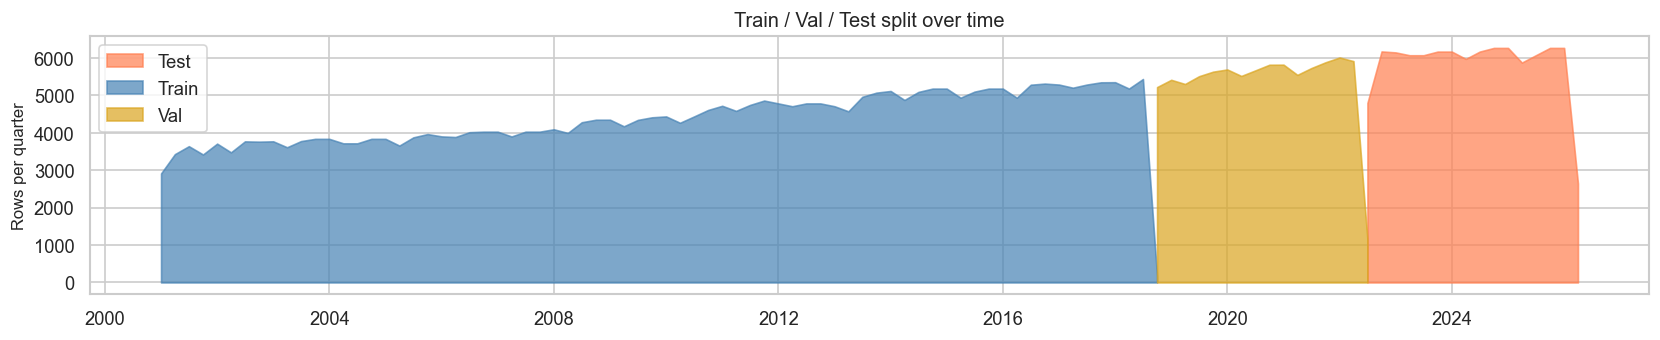

In [18]:
# ── Visualise the split ───────────────────────────────────────────────────────
split_counts = (
    df_model.assign(Split=lambda x: np.where(x['Date'] < val_start, 'Train',
                                    np.where(x['Date'] < test_start, 'Val', 'Test')))
    .groupby([pd.Grouper(key='Date', freq='QE'), 'Split'])
    .size()
    .reset_index(name='Rows')
)

fig, ax = plt.subplots(figsize=(14, 3))
colors = {'Train': 'steelblue', 'Val': 'goldenrod', 'Test': 'coral'}
for split, grp in split_counts.groupby('Split'):
    ax.fill_between(grp['Date'], grp['Rows'], alpha=0.7,
                    color=colors[split], label=split)
ax.set_ylabel('Rows per quarter')
ax.set_title('Train / Val / Test split over time')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend()
plt.tight_layout()
plt.show()

---
## 7. Normalisation & Scaling

**Why RobustScaler?**  
Financial features contain outliers even after winsorisation.  
`RobustScaler` uses the median and IQR instead of mean and std, so it is not distorted by the remaining extreme values.

**Fit on TRAIN ONLY.** Apply the same transform to val and test.  
Fitting on val/test would constitute data leakage.

In [19]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_train = df_train[FEATURE_COLS].values
X_val   = df_val[FEATURE_COLS].values
X_test  = df_test[FEATURE_COLS].values

y_train_reg  = df_train['Target_Ret_5d'].values
y_val_reg    = df_val['Target_Ret_5d'].values
y_test_reg   = df_test['Target_Ret_5d'].values

y_train_cls  = df_train['Target_Dir_5d'].values
y_val_cls    = df_val['Target_Dir_5d'].values
y_test_cls   = df_test['Target_Dir_5d'].values

# Fit scaler ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print(f'X_train : {X_train_scaled.shape}')
print(f'X_val   : {X_val_scaled.shape}')
print(f'X_test  : {X_test_scaled.shape}')
print(f'Features: {FEATURE_COLS}')

X_train : (313288, 49)
X_val   : (85894, 49)
X_test  : (93472, 49)
Features: ['Log_Return', 'Candle_Body_Pct', 'Price_Range_Pct', 'Upper_Shadow', 'Lower_Shadow', 'Gap', 'Log_Volume', 'Volume_Change', 'Volume_Zscore_21d', 'Dollar_Volume', 'SMA_10_Ratio', 'SMA_20_Ratio', 'SMA_50_Ratio', 'SMA_200_Ratio', 'RSI_14', 'MACD_Hist', 'BB_Width', 'BB_Pct', 'ATR_14_Pct', 'Ret_Lag1', 'Ret_Lag2', 'Ret_Lag3', 'Ret_Lag5', 'Ret_Lag10', 'Roll_Mean_5d', 'Roll_Mean_10d', 'Roll_Mean_21d', 'Roll_Mean_63d', 'Roll_Std_5d', 'Roll_Std_10d', 'Roll_Std_21d', 'Roll_Std_63d', 'Roll_Skew_5d', 'Roll_Skew_10d', 'Roll_Skew_21d', 'Roll_Skew_63d', 'Momentum_5d', 'Momentum_21d', 'Momentum_63d', 'Market_Return', 'Excess_Return', 'Beta_63d', 'Corr_Market_63d', 'RS_21d', 'Day_Of_Week', 'Month', 'Quarter', 'Is_Month_End', 'Is_Qtr_End']


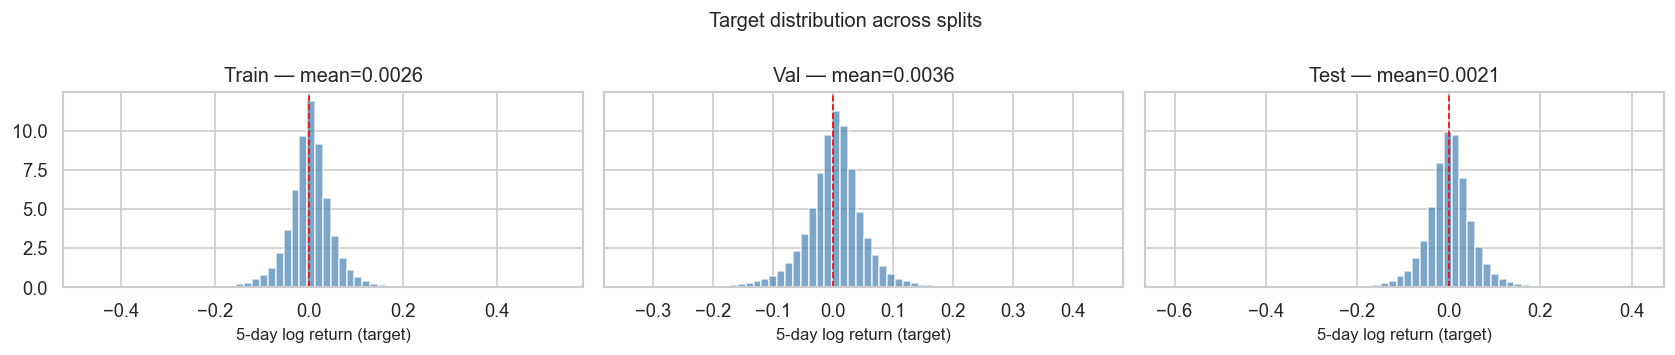


Interpretation:
  - All three splits should have similar distribution shapes (centred near 0).
  - Slightly different means are expected: Val covers COVID volatility,
    Test covers 2023-2026 which includes a strong AI-driven bull market.
  - If any split shows a dramatically shifted distribution, re-check the
    split boundaries and target computation.



In [20]:
# ── Verify no leakage: target distribution should differ between splits ────────
fig, axes = plt.subplots(1, 3, figsize=(14, 3), sharey=True)
for ax, (name, y) in zip(axes, [('Train', y_train_reg),
                                  ('Val',   y_val_reg),
                                  ('Test',  y_test_reg)]):
    ax.hist(y, bins=60, color='steelblue', alpha=0.7, density=True)
    ax.axvline(0, color='red', lw=1, linestyle='--')
    ax.set_title(f'{name} — mean={y.mean():.4f}')
    ax.set_xlabel('5-day log return (target)')
plt.suptitle('Target distribution across splits', fontsize=12)
plt.tight_layout()
plt.show()

print("""
Interpretation:
  - All three splits should have similar distribution shapes (centred near 0).
  - Slightly different means are expected: Val covers COVID volatility,
    Test covers 2023-2026 which includes a strong AI-driven bull market.
  - If any split shows a dramatically shifted distribution, re-check the
    split boundaries and target computation.
""")

---
## 8. Item-Similarity Matrix (for RecSys)

In the RecSys framing, **tickers are items**.  
We build an item-similarity matrix using two approaches:

1. **Return correlation** — tickers that move together are similar (sector proxy)
2. **Feature cosine similarity** — tickers with similar technical profiles are similar

This matrix will be used directly in the content-based and hybrid recommenders.

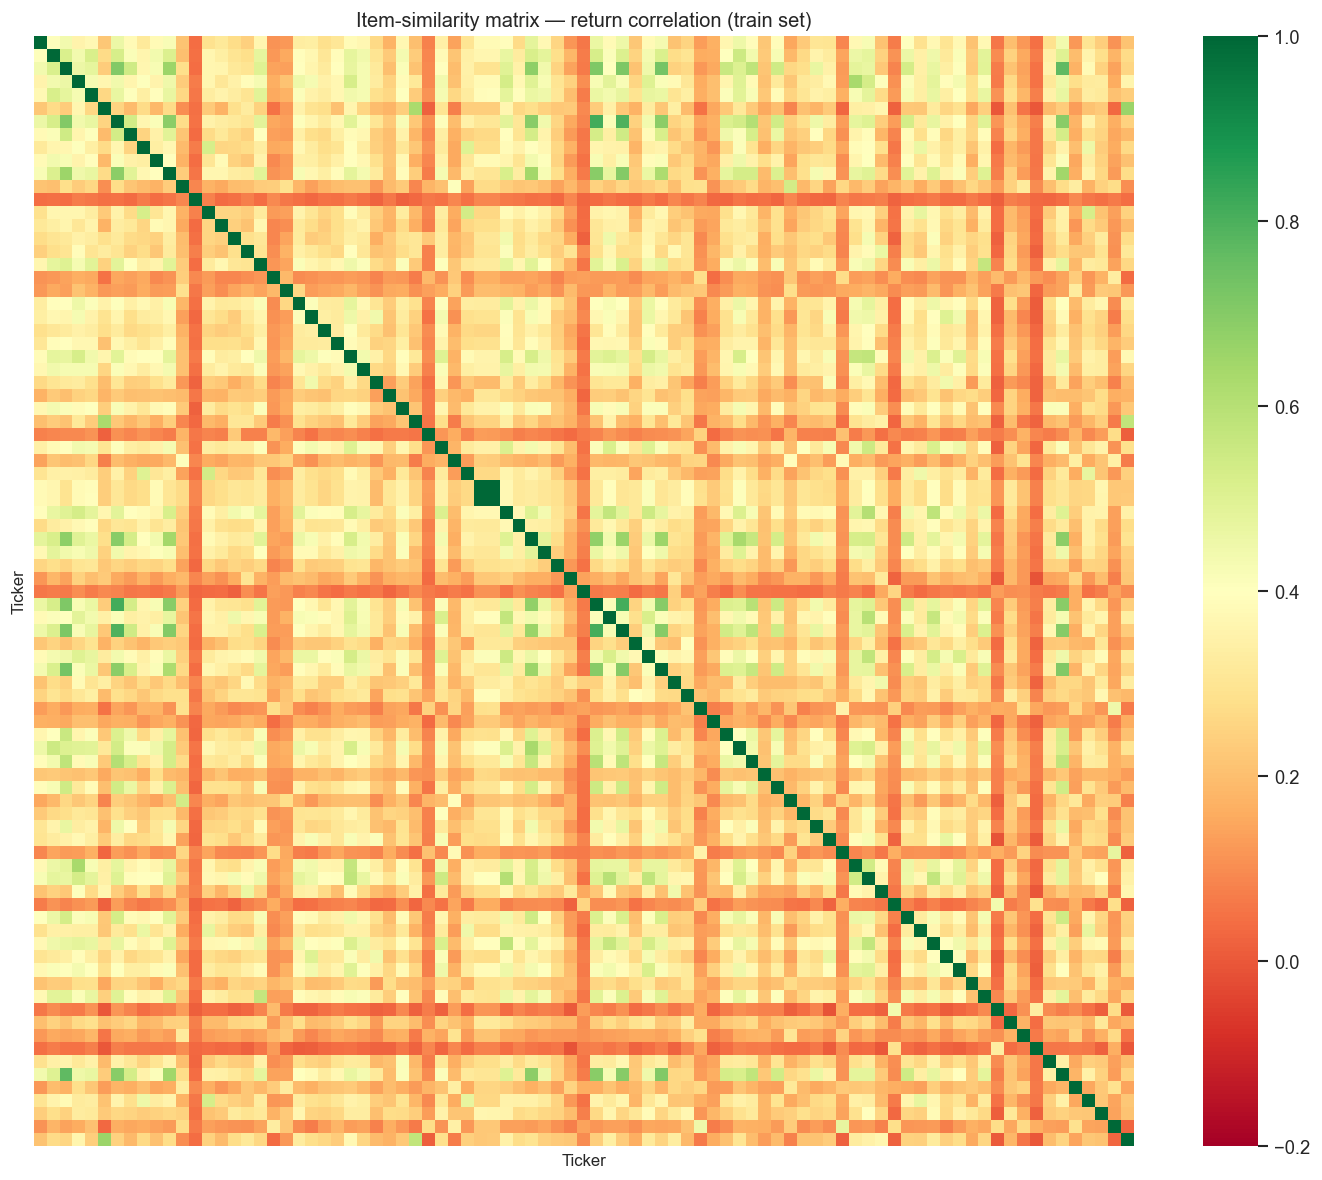

Similarity matrix shape: (85, 85)


In [21]:
# ── 8.1  Return-correlation similarity (computed on TRAIN only) ───────────────
ret_pivot = (
    df_train.pivot_table(index='Date', columns='Ticker', values='Log_Return')
    .fillna(0)
)
ret_corr = ret_pivot.corr()   # shape: n_tickers × n_tickers

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(ret_corr, cmap='RdYlGn', vmin=-0.2, vmax=1.0,
            ax=ax, linewidths=0, xticklabels=False, yticklabels=False)
ax.set_title('Item-similarity matrix — return correlation (train set)')
plt.tight_layout()
plt.show()
print(f'Similarity matrix shape: {ret_corr.shape}')

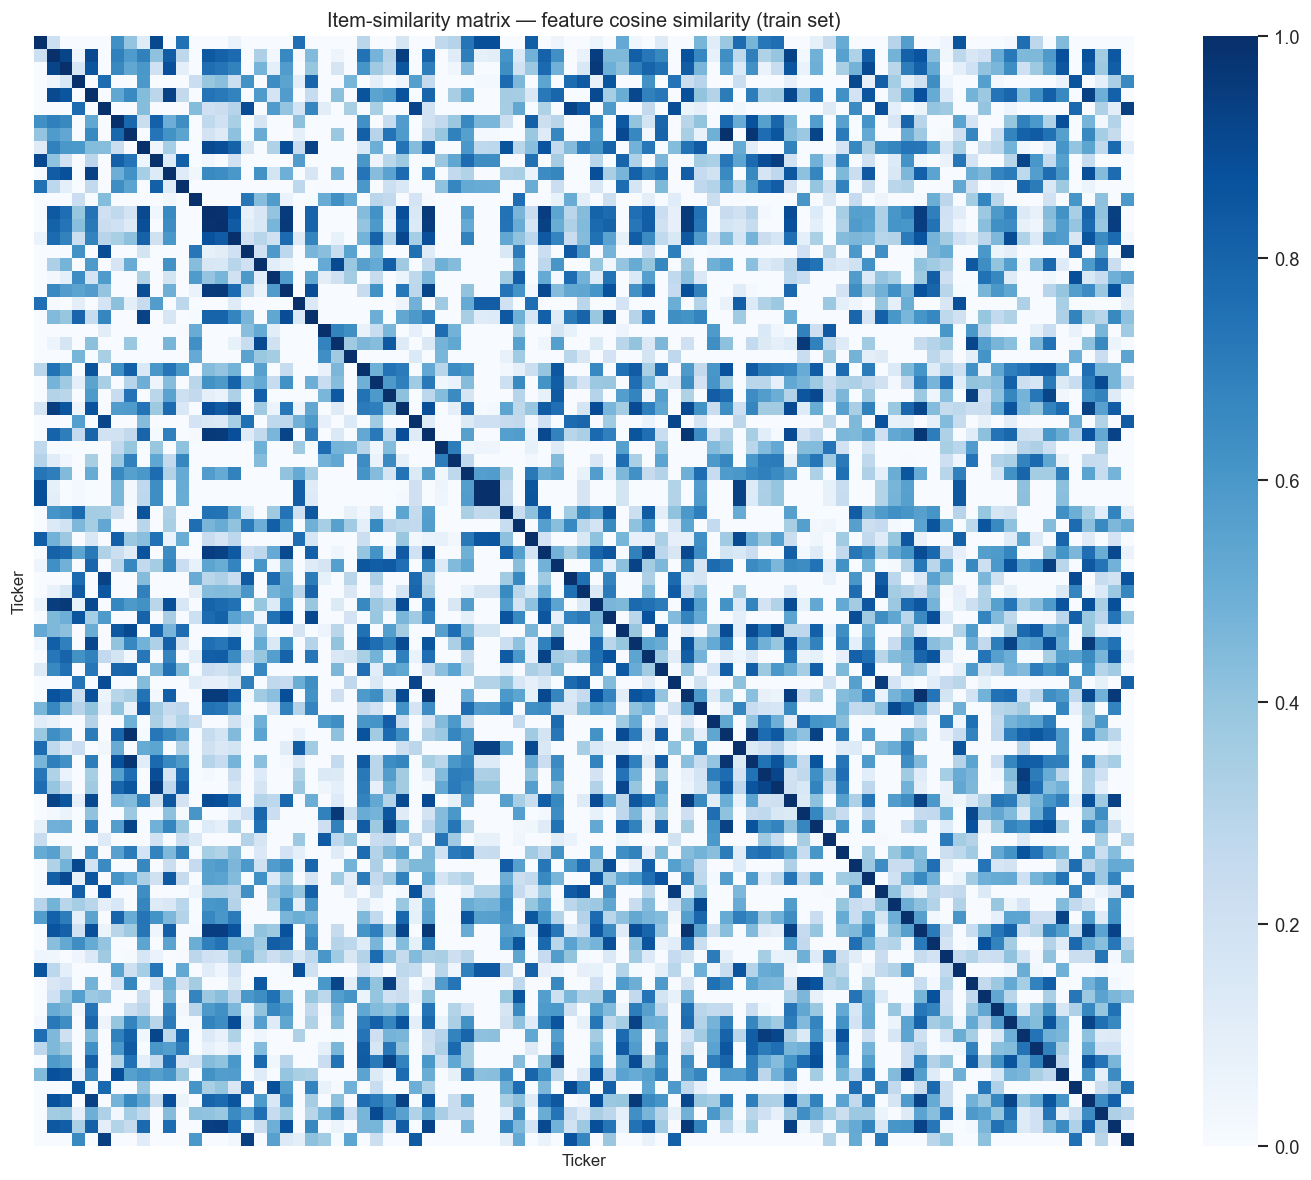

In [22]:
# ── 8.2  Feature cosine similarity ────────────────────────────────────────────
# Average feature vector per ticker over the training period
ticker_features = (
    df_train.groupby('Ticker')[FEATURE_COLS]
    .mean()   # mean feature profile per ticker
)
ticker_features_scaled = scaler.transform(ticker_features.values)
cos_sim = pd.DataFrame(
    cosine_similarity(ticker_features_scaled),
    index=ticker_features.index,
    columns=ticker_features.index
)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cos_sim, cmap='Blues', vmin=0, vmax=1,
            ax=ax, linewidths=0, xticklabels=False, yticklabels=False)
ax.set_title('Item-similarity matrix — feature cosine similarity (train set)')
plt.tight_layout()
plt.show()

In [23]:
# Most similar stocks to a reference ticker
REF = 'AAPL' if 'AAPL' in cos_sim.index else cos_sim.index[0]

print(f'Top 10 most similar tickers to {REF} (cosine similarity on features):')
print(cos_sim[REF].drop(REF).sort_values(ascending=False).head(10).to_string())
print()
print(f'Top 10 most similar tickers to {REF} (return correlation):')
print(ret_corr[REF].drop(REF).sort_values(ascending=False).head(10).to_string())

Top 10 most similar tickers to AAPL (cosine similarity on features):
Ticker
AMZN     0.907885
GOOG     0.879700
GOOGL    0.879678
SBUX     0.861929
INTC     0.821330
MSFT     0.769182
TSLA     0.760877
NVDA     0.758271
CMCSA    0.756998
AVGO     0.748493

Top 10 most similar tickers to AAPL (return correlation):
Ticker
INTC    0.480903
KLAC    0.464889
AMAT    0.457911
MSFT    0.452352
LRCX    0.451916
TXN     0.440257
ADI     0.438191
MCHP    0.436853
PCAR    0.426772
ASML    0.423376


---
## 9. Save Artefacts

In [24]:
import joblib

# ── DataFrames ────────────────────────────────────────────────────────────────
df_train.to_parquet(f'{ARTEFACT_PATH}/df_train.parquet', index=False)
df_val.to_parquet(f'{ARTEFACT_PATH}/df_val.parquet',   index=False)
df_test.to_parquet(f'{ARTEFACT_PATH}/df_test.parquet',  index=False)

# ── Scaled arrays ─────────────────────────────────────────────────────────────
np.save(f'{ARTEFACT_PATH}/X_train.npy', X_train_scaled)
np.save(f'{ARTEFACT_PATH}/X_val.npy',   X_val_scaled)
np.save(f'{ARTEFACT_PATH}/X_test.npy',  X_test_scaled)

np.save(f'{ARTEFACT_PATH}/y_train_reg.npy', y_train_reg)
np.save(f'{ARTEFACT_PATH}/y_val_reg.npy',   y_val_reg)
np.save(f'{ARTEFACT_PATH}/y_test_reg.npy',  y_test_reg)

np.save(f'{ARTEFACT_PATH}/y_train_cls.npy', y_train_cls)
np.save(f'{ARTEFACT_PATH}/y_val_cls.npy',   y_val_cls)
np.save(f'{ARTEFACT_PATH}/y_test_cls.npy',  y_test_cls)

# ── Similarity matrices ───────────────────────────────────────────────────────
ret_corr.to_parquet(f'{ARTEFACT_PATH}/item_sim_corr.parquet')
cos_sim.to_parquet(f'{ARTEFACT_PATH}/item_sim_cosine.parquet')

# ── Scaler + metadata ─────────────────────────────────────────────────────────
joblib.dump(scaler,       f'{ARTEFACT_PATH}/robust_scaler.pkl')
joblib.dump(FEATURE_COLS, f'{ARTEFACT_PATH}/feature_cols.pkl')
joblib.dump(TARGET_COLS,  f'{ARTEFACT_PATH}/target_cols.pkl')

print('All artefacts saved to:', ARTEFACT_PATH)
for f in sorted(os.listdir(ARTEFACT_PATH)):
    size = os.path.getsize(f'{ARTEFACT_PATH}/{f}') / 1024
    print(f'  {f:<35} {size:>8.1f} KB')

All artefacts saved to: ./artefacts
  X_test.npy                           35782.4 KB
  X_train.npy                         119930.7 KB
  X_val.npy                            32881.4 KB
  df_test.parquet                      32060.2 KB
  df_train.parquet                    106992.1 KB
  df_val.parquet                       29402.3 KB
  feature_cols.pkl                         0.7 KB
  item_sim_corr.parquet                   76.7 KB
  item_sim_cosine.parquet                 76.7 KB
  robust_scaler.pkl                        1.2 KB
  target_cols.pkl                          0.1 KB
  y_test_cls.npy                         730.4 KB
  y_test_reg.npy                         730.4 KB
  y_train_cls.npy                       2447.7 KB
  y_train_reg.npy                       2447.7 KB
  y_val_cls.npy                          671.2 KB
  y_val_reg.npy                          671.2 KB


---
## Data Preparation Summary

| Step | Decision | Justification (from EDA) |
|---|---|---|
| Ticker filter | Keep ≥ 1000 trading days | Avoids imbalanced coverage & survivorship bias |
| Zero volume | Forward-fill | Data artefact, not market close |
| OHLC integrity | Drop violating rows | Impossible prices = data errors |
| Returns | Log returns, winsorised 1/99 pct | Fat tails; preserves real extremes |
| Price features | Candle geometry, not raw OHLC | OHLC collinearity > 0.99 |
| Volume | log₁₀, z-score, dollar volume | Right-skewed; raw unusable |
| Technical indicators | SMA, EMA, MACD, RSI, Bollinger, ATR | Standard momentum & mean-reversion signals |
| Lag features | 1/2/3/5/10 day lags | Autocorrelation in returns |
| Rolling stats | 5/10/21/63 day windows | Capture short & medium-term regimes |
| Market features | Beta, excess return, relative strength | RecSys ranks relative to market |
| Target | 5-day forward log return + direction + rank | Regression + classification + ranking |
| Split | 70% train / 15% val / 15% test (temporal) | No lookahead leakage |
| Scaler | RobustScaler fit on train only | Robust to remaining outliers |
| Similarity | Return correlation + cosine similarity | Two views for content-based RecSys |

**Total features:** see `len(FEATURE_COLS)` above  
**Next step:** `1.2-A Modeling` — build baseline, collaborative filter, content-based, and hybrid RecSys models.